# 🧠 Dementia Detection — Results Visualisations
**Cookie Picture Description Task** | Pitt Corpus | 3 Models × 4 Feature Groups

This notebook visualises:
- Dataset class & subject distribution
- Feature group anatomy (acoustic / lexical / syntactic)
- Model comparison (CV-AUC vs Test-AUC)
- ROC curves for all 12 models
- Confusion matrices
- SHAP feature importance (best model)
- PCA of the feature space
- Learning-curve style: CV-AUC vs training-set size sampling

In [1]:
import sys, json, pickle, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay,
)
from sklearn.decomposition import PCA
import shap

warnings.filterwarnings("ignore")

# ── Paths ────────────────────────────────────────────────────────────────────
ROOT        = Path("..").resolve()
COMBINED    = ROOT / "Pitt/processed/combined"
MODELS_DIR  = ROOT / "results/models"
SUMMARY_CSV = MODELS_DIR / "training_summary.csv"

# ── Colour palette ────────────────────────────────────────────────────────────
PALETTE = {
    "Control":  "#4C9BE8",
    "Dementia": "#E8614C",
}
MODEL_COLORS = {
    "logistic_regression": "#5B8DB8",
    "random_forest":       "#59A96A",
    "xgboost":             "#E07B54",
}
FG_COLORS = {
    "acoustic":  "#A78BFA",
    "syntactic": "#34D399",
    "lexical":   "#FBBF24",
    "all":       "#F87171",
}

plt.rcParams.update({"figure.dpi": 130, "font.size": 11})
print("✓  All imports OK")

/Users/eliasskau/miniconda3/envs/dementia-detection/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓  All imports OK


## 1 · Dataset Overview — Cookie Task

In [2]:
df = pd.read_csv(COMBINED / "cookie_features.csv")
df["subject_id"] = df["stem"].apply(lambda s: s.split("-")[0])

# ── column groups ─────────────────────────────────────────────────────────────
acoustic_cols  = [c for c in df.columns if c.startswith("acoustic__")]
lexical_cols   = [c for c in df.columns if c.startswith("lexical__")]
syntactic_cols = [c for c in df.columns if c.startswith("syntactic__")]

print(f"Total sessions : {len(df)}")
print(f"Unique subjects: {df['subject_id'].nunique()}")
print(df["label"].value_counts().to_string())
print(f"\nFeature counts  →  acoustic: {len(acoustic_cols)}  "
      f"lexical: {len(lexical_cols)}  syntactic: {len(syntactic_cols)}")
print("\nSample rows:")
df[["stem","label"] + acoustic_cols[:3]].head(4)

Total sessions : 552
Unique subjects: 292
label
Dementia    309
Control     243

Feature counts  →  acoustic: 88  lexical: 33  syntactic: 23

Sample rows:


,stem,label,acoustic__F0semitoneFrom27.5Hz_sma3nz_amean,acoustic__F0semitoneFrom27.5Hz_sma3nz_stddevNorm,acoustic__F0semitoneFrom27.5Hz_sma3nz_percentile20.0
0,002-0,Control,32.807560,0.151356,30.528254
1,002-1,Control,35.409412,0.213052,30.283808
2,002-2,Control,33.777081,0.085830,31.843809
3,002-3,Control,35.100559,0.139333,31.945707


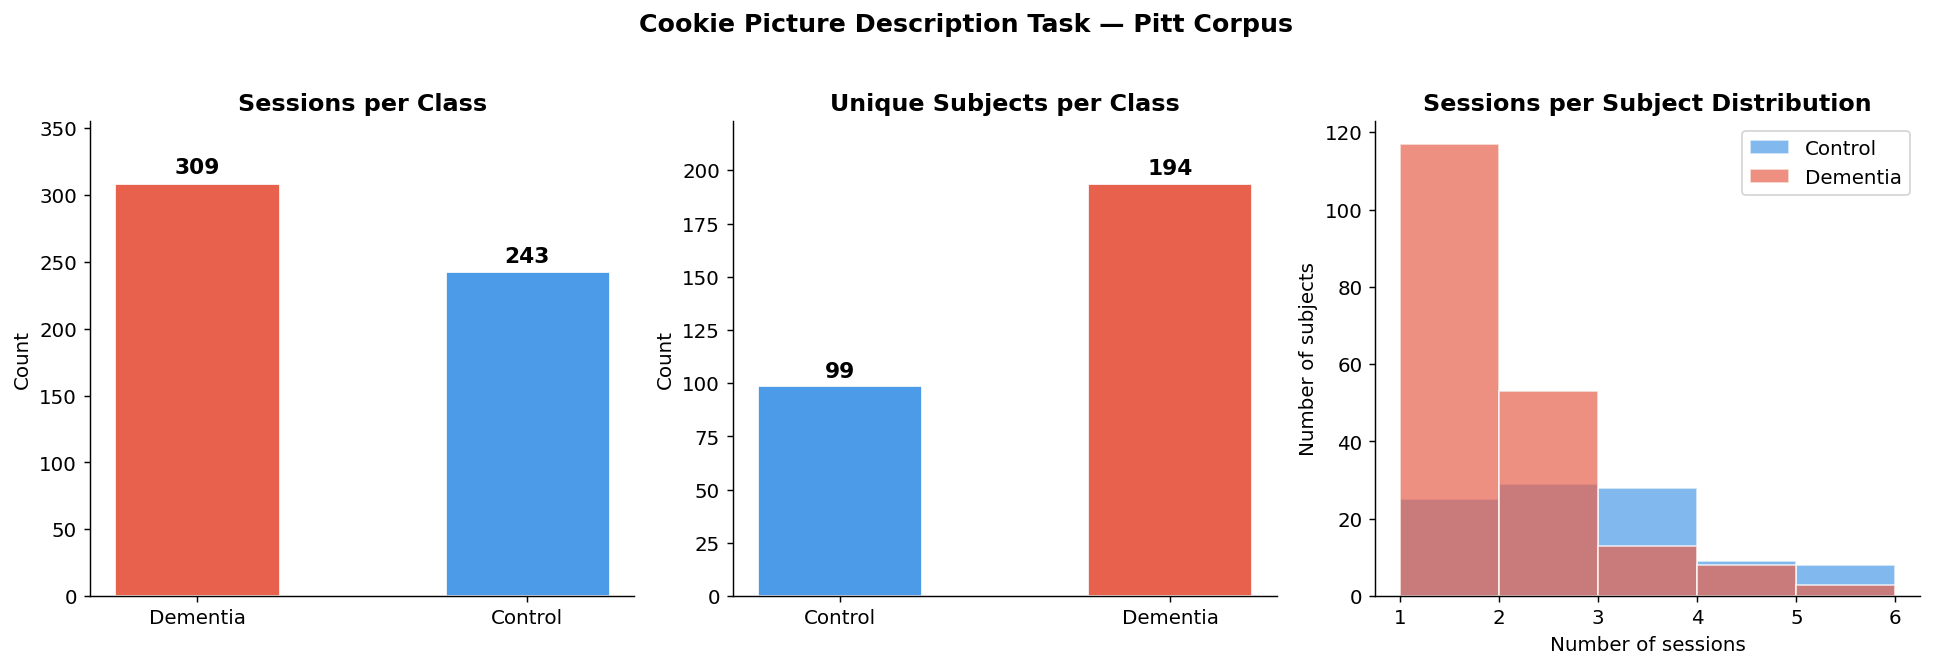

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── (A) Sessions per class ────────────────────────────────────────────────────
session_counts = df["label"].value_counts()
bars = axes[0].bar(session_counts.index, session_counts.values,
                   color=[PALETTE[l] for l in session_counts.index],
                   width=0.5, edgecolor="white", linewidth=1.5)
for bar, v in zip(bars, session_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 4, str(v),
                 ha="center", va="bottom", fontweight="bold", fontsize=12)
axes[0].set_title("Sessions per Class", fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, session_counts.max() * 1.15)
axes[0].spines[["top","right"]].set_visible(False)

# ── (B) Unique subjects per class ────────────────────────────────────────────
subj_counts = df.groupby("label")["subject_id"].nunique()
bars2 = axes[1].bar(subj_counts.index, subj_counts.values,
                    color=[PALETTE[l] for l in subj_counts.index],
                    width=0.5, edgecolor="white", linewidth=1.5)
for bar, v in zip(bars2, subj_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 2, str(v),
                 ha="center", va="bottom", fontweight="bold", fontsize=12)
axes[1].set_title("Unique Subjects per Class", fontweight="bold")
axes[1].set_ylabel("Count")
axes[1].set_ylim(0, subj_counts.max() * 1.15)
axes[1].spines[["top","right"]].set_visible(False)

# ── (C) Sessions-per-subject distribution ────────────────────────────────────
sps = df.groupby(["subject_id","label"]).size().reset_index(name="n_sessions")
for label, grp in sps.groupby("label"):
    axes[2].hist(grp["n_sessions"], bins=range(1, grp["n_sessions"].max()+2),
                 alpha=0.7, label=label, color=PALETTE[label], edgecolor="white")
axes[2].set_title("Sessions per Subject Distribution", fontweight="bold")
axes[2].set_xlabel("Number of sessions")
axes[2].set_ylabel("Number of subjects")
axes[2].legend()
axes[2].spines[["top","right"]].set_visible(False)

plt.suptitle("Cookie Picture Description Task — Pitt Corpus", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 2 · Feature Space Anatomy

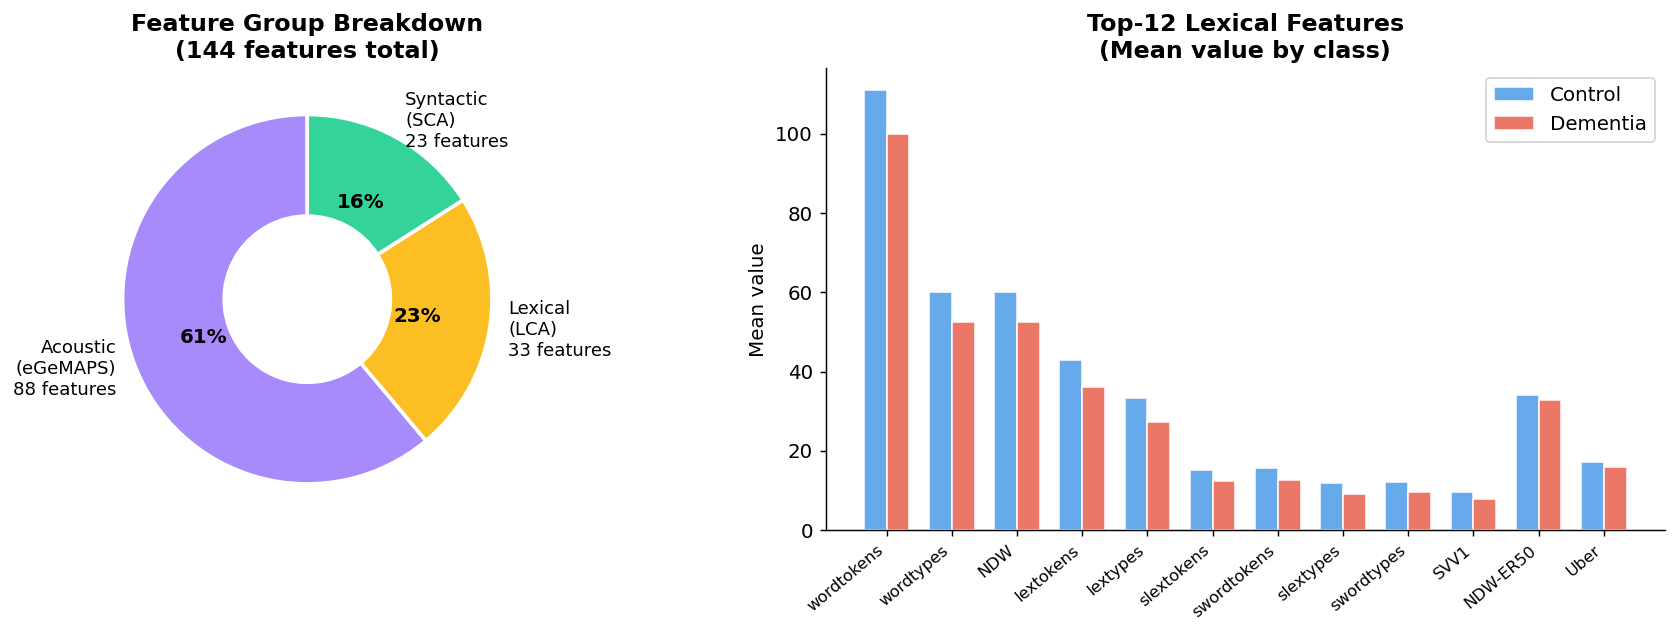

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── (A) Feature count donut ───────────────────────────────────────────────────
sizes  = [len(acoustic_cols), len(lexical_cols), len(syntactic_cols)]
labels = [f"Acoustic\n(eGeMAPS)\n{sizes[0]} features",
          f"Lexical\n(LCA)\n{sizes[1]} features",
          f"Syntactic\n(SCA)\n{sizes[2]} features"]
colors = [FG_COLORS["acoustic"], FG_COLORS["lexical"], FG_COLORS["syntactic"]]
wedges, texts, autotexts = axes[0].pie(
    sizes, labels=labels, colors=colors,
    autopct="%1.0f%%", startangle=90,
    wedgeprops=dict(width=0.55, edgecolor="white", linewidth=2),
    textprops=dict(fontsize=10),
)
for at in autotexts:
    at.set_fontsize(11); at.set_fontweight("bold")
axes[0].set_title("Feature Group Breakdown\n(144 features total)", fontweight="bold")

# ── (B) Mean absolute feature value by class — top lexical features ───────────
top_lex = (df.groupby("label")[lexical_cols]
             .mean()
             .T
             .assign(diff=lambda x: abs(x["Dementia"] - x["Control"]))
             .nlargest(12, "diff")
             .drop(columns="diff"))
short_names = [c.replace("lexical__","").split(" ")[0] for c in top_lex.index]
x = np.arange(len(short_names))
w = 0.35
axes[1].bar(x - w/2, top_lex["Control"],  w, label="Control",  color=PALETTE["Control"],  alpha=0.85, edgecolor="white")
axes[1].bar(x + w/2, top_lex["Dementia"], w, label="Dementia", color=PALETTE["Dementia"], alpha=0.85, edgecolor="white")
axes[1].set_xticks(x)
axes[1].set_xticklabels(short_names, rotation=40, ha="right", fontsize=9)
axes[1].set_title("Top-12 Lexical Features\n(Mean value by class)", fontweight="bold")
axes[1].set_ylabel("Mean value")
axes[1].legend()
axes[1].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()

## 3 · Model Comparison — CV-AUC vs Test-AUC

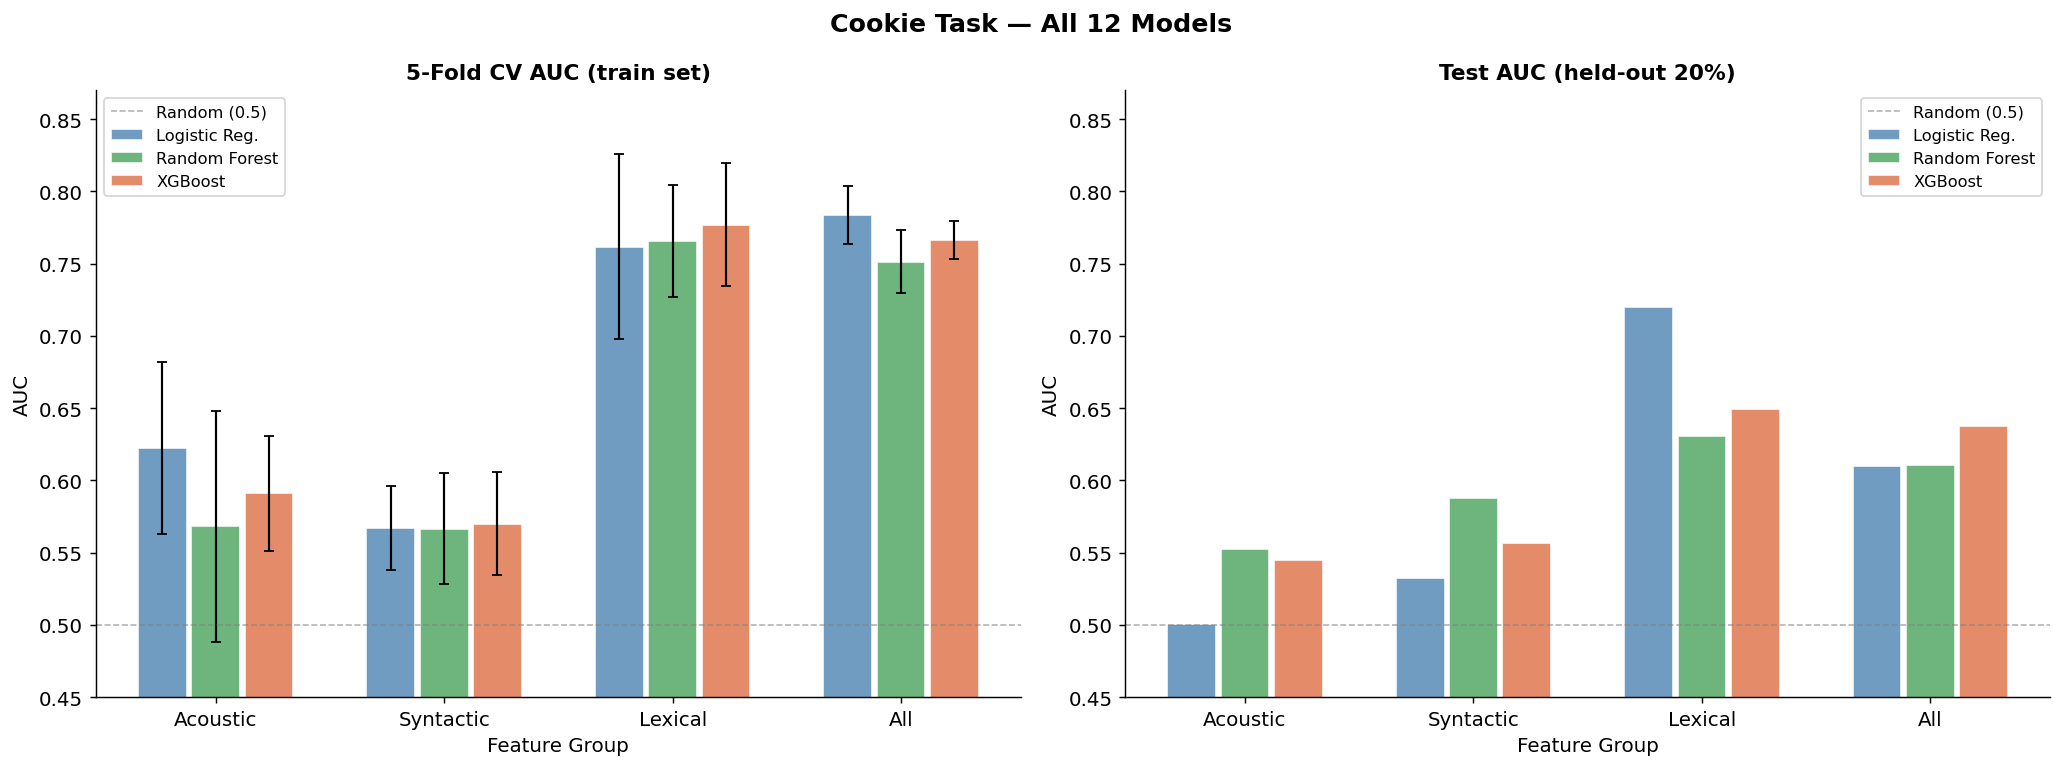

In [5]:
summary = pd.read_csv(SUMMARY_CSV)

MODEL_LABELS = {
    "logistic_regression": "Logistic Reg.",
    "random_forest":       "Random Forest",
    "xgboost":             "XGBoost",
}
FG_ORDER = ["acoustic", "syntactic", "lexical", "all"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax_idx, (metric, title) in enumerate([("cv_auc_mean","5-Fold CV AUC (train set)"),
                                           ("test_auc",   "Test AUC (held-out 20%)")]):
    ax = axes[ax_idx]
    n_models = len(MODEL_LABELS)
    n_fg     = len(FG_ORDER)
    group_w  = 0.7
    bar_w    = group_w / n_models
    x        = np.arange(n_fg)

    for i, (mkey, mlabel) in enumerate(MODEL_LABELS.items()):
        vals  = []
        errs  = []
        for fg in FG_ORDER:
            row = summary[(summary.model == mkey) & (summary.feature_group == fg)]
            vals.append(float(row[metric].values[0]) if len(row) else 0)
            if metric == "cv_auc_mean":
                errs.append(float(row["cv_auc_std"].values[0]) if len(row) else 0)
            else:
                errs.append(0)
        offset = (i - n_models/2 + 0.5) * bar_w
        bars = ax.bar(x + offset, vals, bar_w - 0.02,
                      label=mlabel, color=MODEL_COLORS[mkey],
                      alpha=0.87, edgecolor="white")
        if any(e > 0 for e in errs):
            ax.errorbar(x + offset, vals, yerr=errs, fmt="none",
                        color="black", capsize=3, linewidth=1.2)

    ax.set_xticks(x)
    ax.set_xticklabels([f.capitalize() for f in FG_ORDER], fontsize=11)
    ax.set_xlabel("Feature Group", fontsize=11)
    ax.set_ylabel("AUC", fontsize=11)
    ax.set_title(title, fontweight="bold", fontsize=12)
    ax.set_ylim(0.45, 0.87)
    ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.9, alpha=0.6, label="Random (0.5)")
    ax.legend(fontsize=9)
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("Cookie Task — All 12 Models", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 4 · Performance Metrics Heatmap

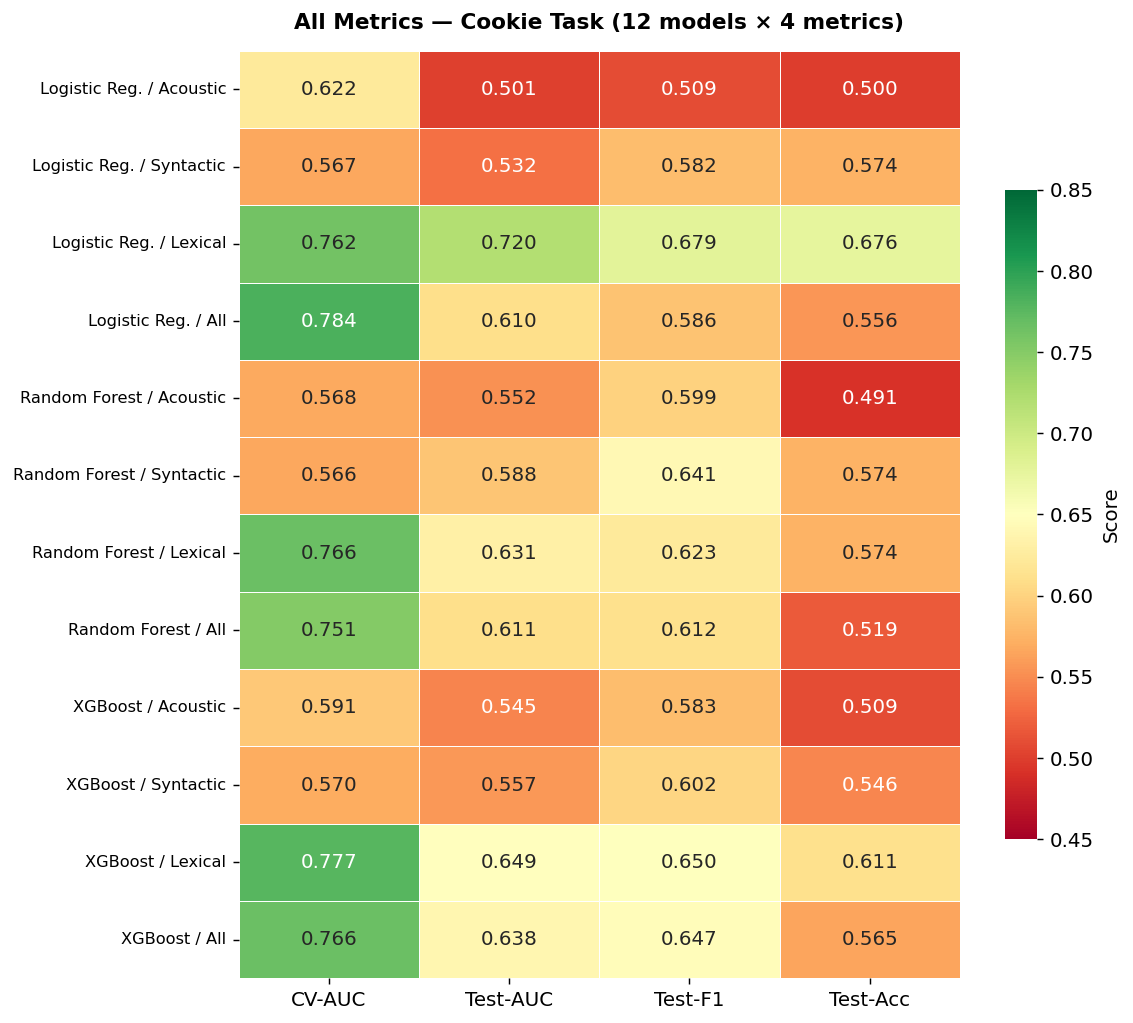

In [6]:
metrics = ["cv_auc_mean", "test_auc", "test_f1", "test_acc"]
metric_labels = ["CV-AUC", "Test-AUC", "Test-F1", "Test-Acc"]

summary["label"] = summary["model"].map(MODEL_LABELS) + " / " + summary["feature_group"].str.capitalize()
pivot = summary.set_index("label")[metrics]
pivot.columns = metric_labels

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(
    pivot, annot=True, fmt=".3f", cmap="RdYlGn",
    vmin=0.45, vmax=0.85,
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "Score", "shrink": 0.7},
    ax=ax,
)
ax.set_title("All Metrics — Cookie Task (12 models × 4 metrics)", fontweight="bold", fontsize=12, pad=12)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()
plt.show()

## 5 · ROC Curves — All 12 Models

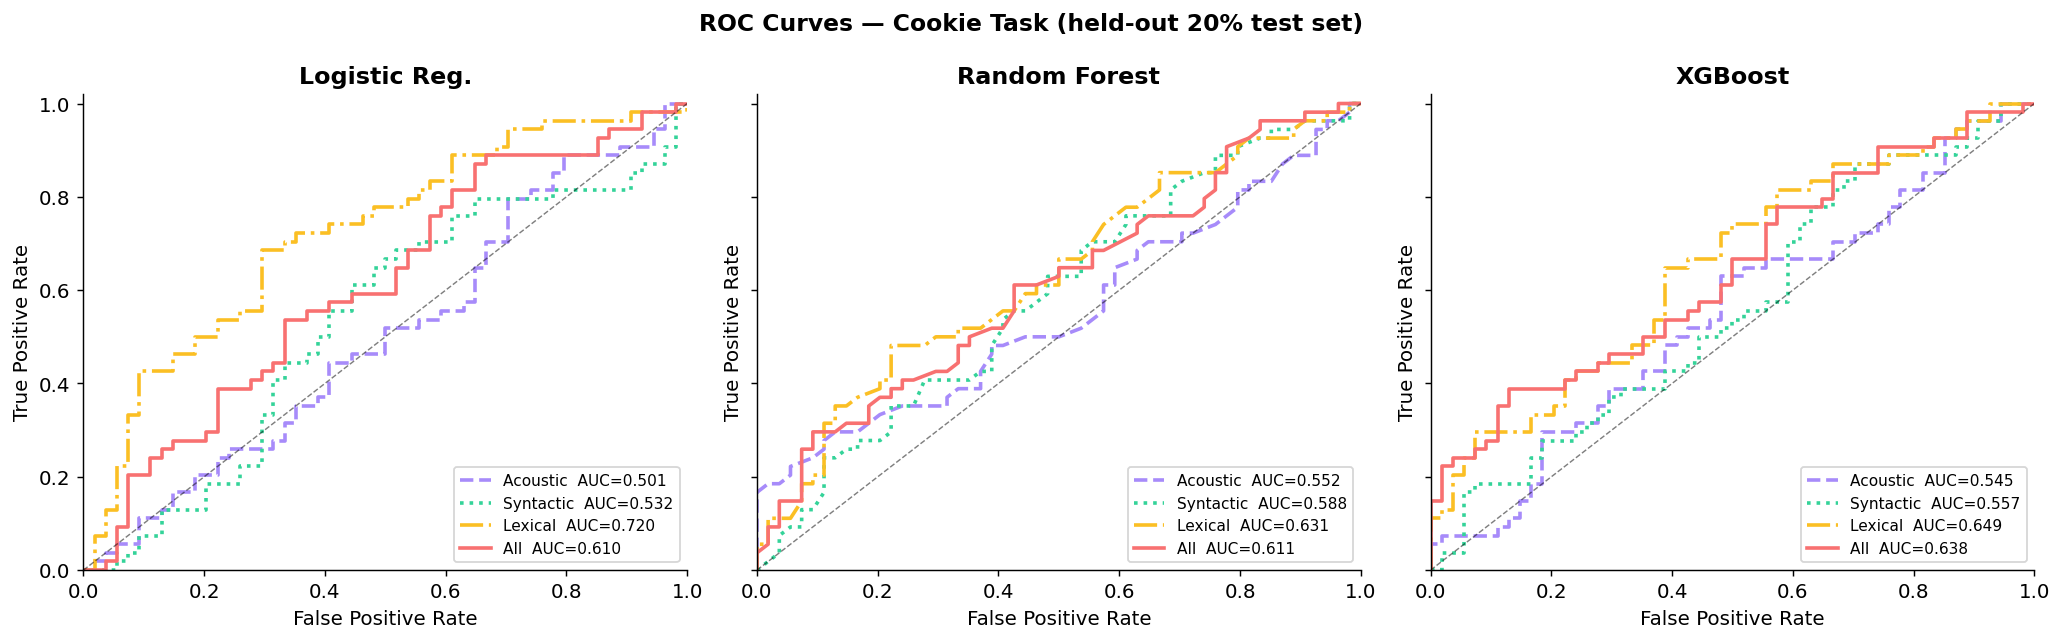

In [7]:
def load_model(model_key, fg):
    path = MODELS_DIR / "cookie" / f"{model_key}__{fg}.pkl"
    with open(path, "rb") as f:
        return pickle.load(f)

def get_test_data(pkl, df):
    """Re-create the same 80/20 subject split used during training."""
    from sklearn.model_selection import StratifiedKFold
    df = df.copy()
    df["subject_id"] = df["stem"].apply(lambda s: s.split("-")[0])
    le_enc = LabelEncoder()
    y_enc  = le_enc.fit_transform(df["label"].values)
    subj   = df["subject_id"].values
    unique_subj = np.unique(subj)
    subj_label  = np.array([int(y_enc[subj==s].mean()>=0.5) for s in unique_subj])
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    _, test_idx = next(skf.split(unique_subj, subj_label))
    test_subjects = set(unique_subj[test_idx])
    df_test = df[df["subject_id"].isin(test_subjects)]
    X_test  = df_test[pkl["feature_cols"]].values.astype(np.float32)
    y_test  = pkl["label_encoder"].transform(df_test["label"].values)
    return X_test, y_test

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
LS = {"acoustic":"--", "syntactic":":", "lexical":"-.", "all":"-"}

for ax, (mkey, mlabel) in zip(axes, MODEL_LABELS.items()):
    for fg in FG_ORDER:
        pkl  = load_model(mkey, fg)
        X_t, y_t = get_test_data(pkl, df)
        y_prob = pkl["pipeline"].predict_proba(X_t)[:, 1]
        fpr, tpr, _ = roc_curve(y_t, y_prob)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, linestyle=LS[fg], linewidth=2.0,
                color=FG_COLORS[fg],
                label=f"{fg.capitalize()}  AUC={roc_auc:.3f}")
    ax.plot([0,1],[0,1],"k--", linewidth=0.8, alpha=0.5)
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(mlabel, fontweight="bold")
    ax.legend(fontsize=8.5, loc="lower right")
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("ROC Curves — Cookie Task (held-out 20% test set)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 6 · Confusion Matrices — Best Feature Group per Model

Best feature group per model:
              model feature_group  test_auc
logistic_regression       lexical  0.720165
      random_forest       lexical  0.630830
            xgboost       lexical  0.649177


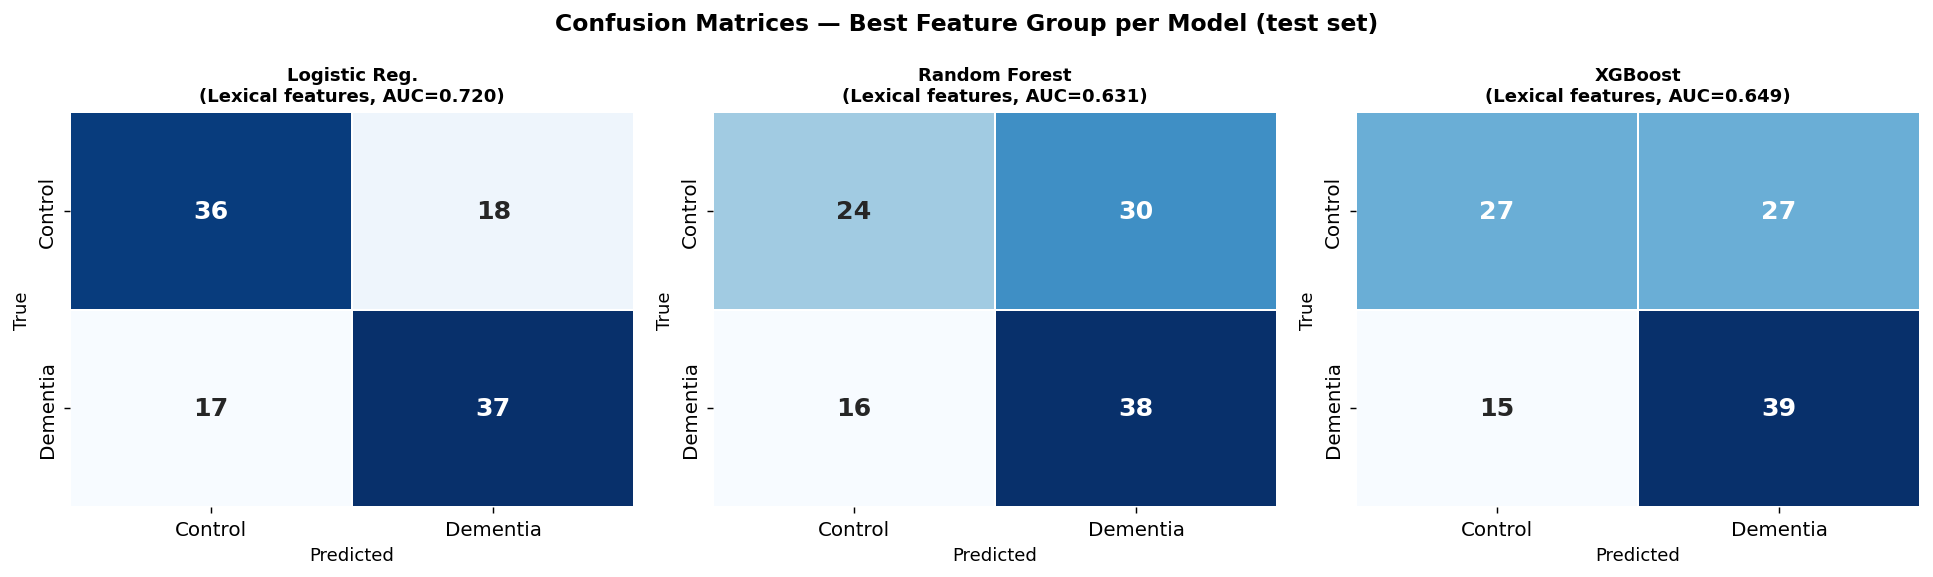

In [8]:
# Best feature group per model = highest test_auc
best_fg = (summary.sort_values("test_auc", ascending=False)
                  .groupby("model")
                  .first()
                  .reset_index()[["model","feature_group","test_auc"]])
print("Best feature group per model:")
print(best_fg.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (_, row) in zip(axes, best_fg.iterrows()):
    mkey = row["model"]
    fg   = row["feature_group"]
    pkl  = load_model(mkey, fg)
    X_t, y_t = get_test_data(pkl, df)
    y_pred = pkl["pipeline"].predict(X_t)
    class_names = pkl["label_encoder"].classes_

    cm = confusion_matrix(y_t, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names,
                linewidths=1, linecolor="white", ax=ax,
                cbar=False, annot_kws={"size": 14, "weight": "bold"})
    ax.set_xlabel("Predicted", fontsize=10)
    ax.set_ylabel("True", fontsize=10)
    ax.set_title(f"{MODEL_LABELS[mkey]}\n({fg.capitalize()} features, AUC={row['test_auc']:.3f})",
                 fontweight="bold", fontsize=10)

plt.suptitle("Confusion Matrices — Best Feature Group per Model (test set)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 7 · SHAP Feature Importance — Best Model (Logistic Regression / Lexical)

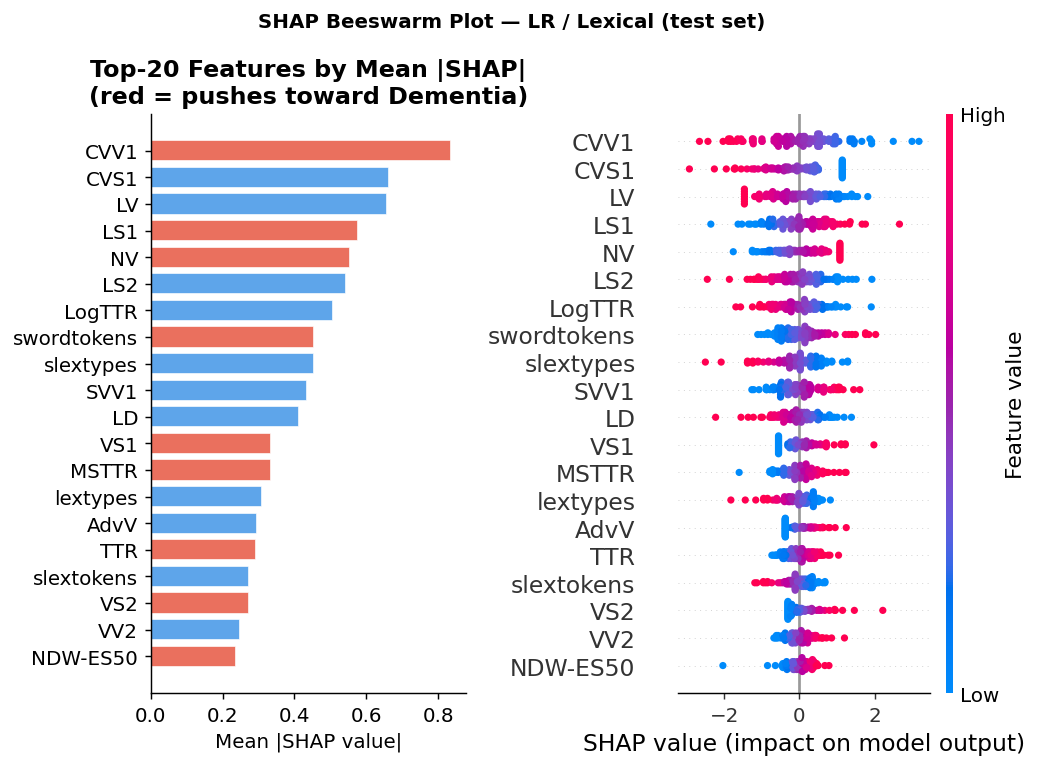

<Figure size 832x624 with 0 Axes>

In [9]:
# Overall best model by test AUC = logistic_regression / lexical (0.720)
pkl_best = load_model("logistic_regression", "lexical")
X_t, y_t = get_test_data(pkl_best, df)

pipe   = pkl_best["pipeline"]
scaler = pipe.named_steps["scaler"]
clf    = pipe.named_steps["clf"]
X_scaled = scaler.transform(X_t)

explainer   = shap.LinearExplainer(clf, X_scaled, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_scaled)   # shape: (n_samples, n_features)

feat_names = [c.replace("lexical__","").split(" (")[0] for c in pkl_best["feature_cols"]]
mean_abs   = np.abs(shap_values).mean(axis=0)
order      = np.argsort(mean_abs)[::-1][:20]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── (A) Mean |SHAP| bar chart ─────────────────────────────────────────────────
bars = axes[0].barh(
    [feat_names[i] for i in order[::-1]],
    mean_abs[order[::-1]],
    color=[PALETTE["Dementia"] if shap_values[:,i].mean()>0 else PALETTE["Control"]
           for i in order[::-1]],
    edgecolor="white", alpha=0.9,
)
axes[0].set_xlabel("Mean |SHAP value|")
axes[0].set_title("Top-20 Features by Mean |SHAP|\n(red = pushes toward Dementia)", fontweight="bold")
axes[0].spines[["top","right"]].set_visible(False)

# ── (B) SHAP beeswarm (summary plot via matplotlib) ──────────────────────────
shap.summary_plot(
    shap_values[:, order[:20]],
    X_scaled[:, order[:20]],
    feature_names=[feat_names[i] for i in order[:20]],
    plot_type="dot",
    show=False,
    plot_size=None,
    color_bar=True,
)
# shap.summary_plot draws on the current figure; grab it and attach to our axis
shap_fig = plt.gcf()
shap_fig.set_size_inches(8, 6)
shap_fig.suptitle("SHAP Beeswarm Plot — LR / Lexical (test set)", fontweight="bold", fontsize=11)
plt.tight_layout()
plt.show()

# Show the bar chart separately
plt.figure(fig.number)
plt.tight_layout()
plt.show()

## 8 · PCA of the Feature Space

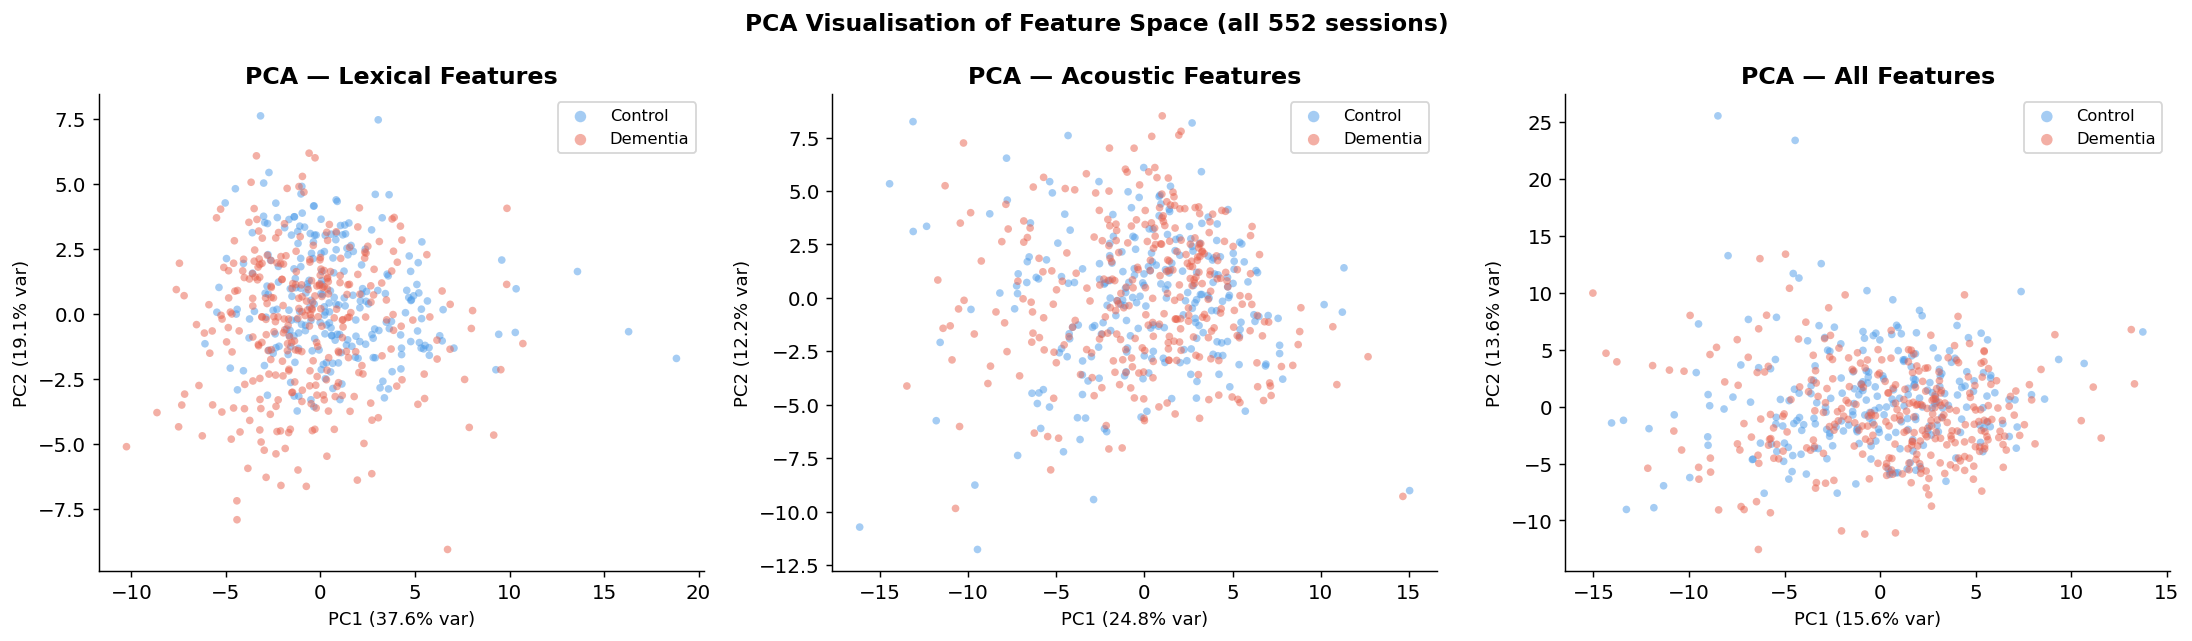

In [10]:
from sklearn.preprocessing import StandardScaler as SS

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
feat_groups = [
    ("Lexical",   lexical_cols,   "lexical"),
    ("Acoustic",  acoustic_cols,  "acoustic"),
    ("All",       lexical_cols + acoustic_cols + syntactic_cols, "all"),
]

for ax, (title, cols, _) in zip(axes, feat_groups):
    X_all = df[cols].values.astype(np.float32)
    X_all = np.nan_to_num(X_all)
    X_sc  = SS().fit_transform(X_all)
    pca   = PCA(n_components=2, random_state=42)
    Z     = pca.fit_transform(X_sc)
    ev    = pca.explained_variance_ratio_ * 100

    for label in ["Control", "Dementia"]:
        mask = df["label"].values == label
        ax.scatter(Z[mask, 0], Z[mask, 1],
                   c=PALETTE[label], label=label,
                   alpha=0.5, s=18, edgecolors="none")

    ax.set_xlabel(f"PC1 ({ev[0]:.1f}% var)", fontsize=10)
    ax.set_ylabel(f"PC2 ({ev[1]:.1f}% var)", fontsize=10)
    ax.set_title(f"PCA — {title} Features", fontweight="bold")
    ax.legend(markerscale=1.5, fontsize=9)
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("PCA Visualisation of Feature Space (all 552 sessions)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 9 · CV-AUC vs Test-AUC Scatter (Overfitting Check)

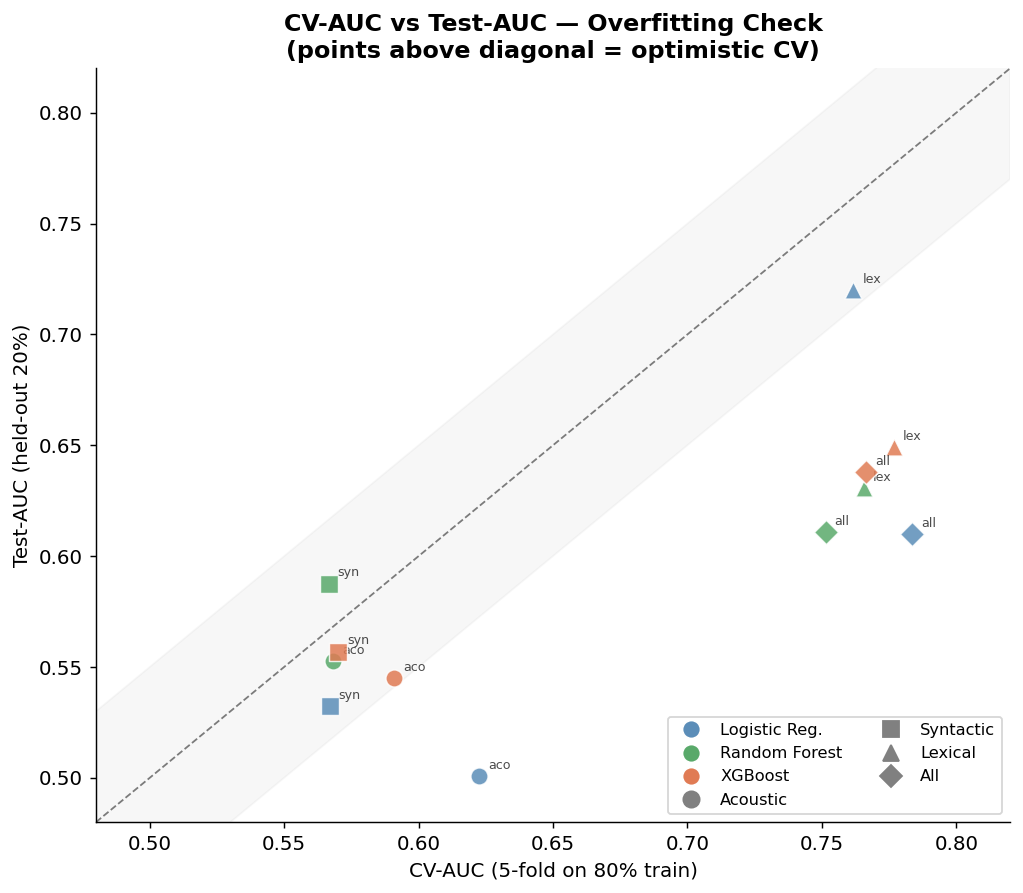

In [11]:
fig, ax = plt.subplots(figsize=(8, 7))

for _, row in summary.iterrows():
    ax.scatter(row["cv_auc_mean"], row["test_auc"],
               color=MODEL_COLORS[row["model"]],
               marker={"acoustic":"o","syntactic":"s","lexical":"^","all":"D"}[row["feature_group"]],
               s=90, zorder=3, alpha=0.85,
               edgecolors="white", linewidths=0.8)
    ax.annotate(f"{row['feature_group'][:3]}",
                (row["cv_auc_mean"], row["test_auc"]),
                textcoords="offset points", xytext=(5, 4), fontsize=7, alpha=0.7)

# Perfect calibration line
lims = [0.48, 0.82]
ax.plot(lims, lims, "k--", linewidth=1, alpha=0.5, label="CV = Test (ideal)")
ax.fill_between(lims, [l-0.05 for l in lims], [l+0.05 for l in lims],
                alpha=0.06, color="grey", label="±0.05 band")

# Model legend
from matplotlib.lines import Line2D
model_handles = [Line2D([0],[0], marker="o", color="w", markerfacecolor=c,
                         markersize=10, label=MODEL_LABELS[k])
                 for k, c in MODEL_COLORS.items()]
fg_handles = [Line2D([0],[0], marker=m, color="grey", markersize=9,
                      label=fg.capitalize(), linestyle="None")
              for fg, m in zip(["acoustic","syntactic","lexical","all"],["o","s","^","D"])]

ax.legend(handles=model_handles + fg_handles, fontsize=9, ncol=2, loc="lower right")
ax.set_xlabel("CV-AUC (5-fold on 80% train)", fontsize=11)
ax.set_ylabel("Test-AUC (held-out 20%)", fontsize=11)
ax.set_title("CV-AUC vs Test-AUC — Overfitting Check\n(points above diagonal = optimistic CV)", fontweight="bold")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 10 · Learning Curves (Training Size vs CV-AUC)

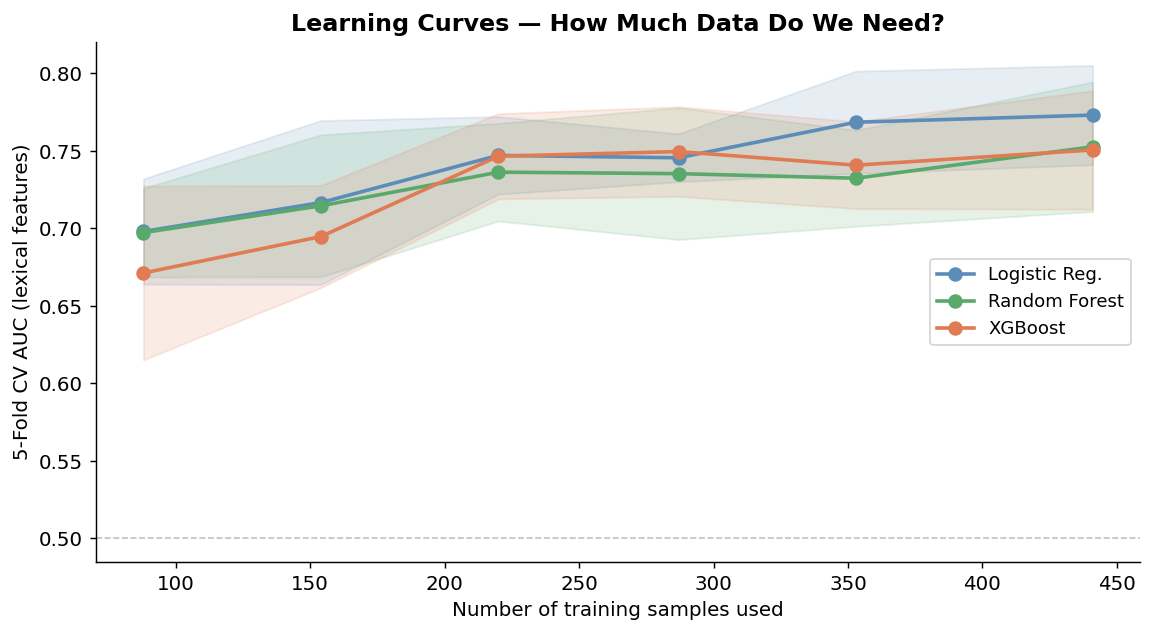

In [12]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone as sk_clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

# Use the lexical feature set (best discriminating group) on the full dataset
cols_lex = lexical_cols
X_lc = df[cols_lex].values.astype(np.float32)
X_lc = np.nan_to_num(X_lc)
le_lc = LabelEncoder()
y_lc = le_lc.fit_transform(df["label"].values)

train_fracs = [0.20, 0.35, 0.50, 0.65, 0.80, 1.00]
LEARN_MODELS = {
    "logistic_regression": Pipeline([("sc", StandardScaler()),
                                     ("clf", LogisticRegression(max_iter=2000, C=1.0,
                                             class_weight="balanced", random_state=42))]),
    "random_forest":       RandomForestClassifier(n_estimators=100, class_weight="balanced",
                                                  random_state=42, n_jobs=-1),
    "xgboost":             XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05,
                                         eval_metric="logloss", random_state=42, n_jobs=-1),
}

from sklearn.metrics import roc_auc_score as ras
rng = np.random.default_rng(42)
results_lc = {m: {"mean": [], "std": []} for m in LEARN_MODELS}

for frac in train_fracs:
    for mkey, estimator in LEARN_MODELS.items():
        fold_aucs = []
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        for tr_idx, val_idx in skf.split(X_lc, y_lc):
            n_use = max(int(len(tr_idx) * frac), 20)
            chosen = rng.choice(tr_idx, size=n_use, replace=False)
            if len(np.unique(y_lc[chosen])) < 2:
                continue
            mdl = sk_clone(estimator)
            mdl.fit(X_lc[chosen], y_lc[chosen])
            prob = mdl.predict_proba(X_lc[val_idx])[:, 1]
            if len(np.unique(y_lc[val_idx])) > 1:
                fold_aucs.append(ras(y_lc[val_idx], prob))
        results_lc[mkey]["mean"].append(np.mean(fold_aucs) if fold_aucs else np.nan)
        results_lc[mkey]["std"].append(np.std(fold_aucs)  if fold_aucs else 0)

n_total = len(X_lc)
x_vals  = [int(f * n_total * 0.8) for f in train_fracs]  # ~80% used for train in practice

fig, ax = plt.subplots(figsize=(9, 5))
for mkey, color in MODEL_COLORS.items():
    mu  = np.array(results_lc[mkey]["mean"])
    std = np.array(results_lc[mkey]["std"])
    ax.plot(x_vals, mu, "-o", color=color, linewidth=2, markersize=7, label=MODEL_LABELS[mkey])
    ax.fill_between(x_vals, mu - std, mu + std, alpha=0.15, color=color)

ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.9, alpha=0.5)
ax.set_xlabel("Number of training samples used", fontsize=11)
ax.set_ylabel("5-Fold CV AUC (lexical features)", fontsize=11)
ax.set_title("Learning Curves — How Much Data Do We Need?", fontweight="bold")
ax.legend(fontsize=10)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()